In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from flash_ansr import get_path

In [2]:
# Load all rebuttal results
PATH = get_path('results', 'evaluation', 'rebuttal')

models = ['v23.0-20M-A-S1', 'v23.0-20M-A-Y1', 'v23.0-20M-A-U1', 'v23.0-20M-A-Y50K']
labels = ['SimpliPy', 'SymPy', 'Unsimplified', 'SymPy 50K']
choices_list = [1, 4, 16, 64, 256, 1024]

results = {}
for model in models:
    results[model] = {}
    for c in choices_list:
        path = os.path.join(PATH, model, 'fastsrb', f'choices_{c:05d}.pkl')
        with open(path, 'rb') as f:
            results[model][c] = pickle.load(f)
        n = len(results[model][c].get('y_pred_val', results[model][c].get('y_pred', [])))
        print(f'{model} choices={c}: {n} samples')

v23.0-20M-A-S1 choices=1: 600 samples
v23.0-20M-A-S1 choices=4: 600 samples
v23.0-20M-A-S1 choices=16: 600 samples
v23.0-20M-A-S1 choices=64: 600 samples
v23.0-20M-A-S1 choices=256: 600 samples
v23.0-20M-A-Y1 choices=1: 600 samples
v23.0-20M-A-Y1 choices=4: 600 samples
v23.0-20M-A-Y1 choices=16: 600 samples
v23.0-20M-A-Y1 choices=64: 600 samples
v23.0-20M-A-Y1 choices=256: 600 samples
v23.0-20M-A-U1 choices=1: 600 samples
v23.0-20M-A-U1 choices=4: 600 samples
v23.0-20M-A-U1 choices=16: 600 samples
v23.0-20M-A-U1 choices=64: 600 samples
v23.0-20M-A-U1 choices=256: 600 samples


In [3]:
# Compute R² for each sample (validation set)
def compute_r2(y_true, y_pred):
    """Compute R² per sample, handling edge cases."""
    r2_values = []
    for yt, yp in zip(y_true, y_pred):
        if yt is None or yp is None:
            r2_values.append(np.nan)
            continue
        yt = np.asarray(yt).flatten()
        yp = np.asarray(yp).flatten()
        if len(yt) == 0 or np.var(yt) == 0:
            r2_values.append(np.nan)
            continue
        ss_res = np.nanmean((yt - yp) ** 2)
        ss_tot = np.nanvar(yt)
        r2_values.append(1 - ss_res / ss_tot)
    return np.array(r2_values)


def compute_fvu(y_true, y_pred):
    """Compute FVU (Fraction of Variance Unexplained) per sample."""
    fvu_values = []
    for yt, yp in zip(y_true, y_pred):
        if yt is None or yp is None:
            fvu_values.append(np.inf)
            continue
        yt = np.asarray(yt).flatten()
        yp = np.asarray(yp).flatten()
        if len(yt) == 0:
            fvu_values.append(np.inf)
            continue
        var_y = np.var(yt)
        if var_y == 0:
            fvu_values.append(np.inf)
            continue
        mse = np.mean((yt - yp) ** 2)
        fvu_values.append(mse / var_y)
    return np.array(fvu_values)


def compute_expression_length_ratio(gt_prefix, pred_prefix):
    """Compute ratio of predicted expression length to ground truth length."""
    ratios = []
    for gt, pred in zip(gt_prefix, pred_prefix):
        if gt is None or pred is None or len(gt) == 0:
            ratios.append(np.inf)
            continue
        ratios.append(len(pred) / len(gt))
    return np.array(ratios)


def naninfmean(a):
    a = np.array([x for x in a if x is not None], dtype=float)
    return np.nanmean(a[np.isfinite(a)])


EPS32 = np.finfo(np.float32).eps

# Compute metrics for all models and choices
metrics = {}
for model in models:
    metrics[model] = {}
    for c in choices_list:
        data = results[model][c]
        # Use validation set if available, else fit set
        y_key = 'y_val' if 'y_val' in data else 'y'
        yp_key = 'y_pred_val' if 'y_pred_val' in data else 'y_pred'
        
        r2 = compute_r2(data[y_key], data[yp_key])
        recovery = np.nanmean(r2 > 0.99)
        median_r2 = np.nanmedian(r2)
        
        fvu = compute_fvu(data[y_key], data[yp_key])
        nrr = np.mean(fvu <= EPS32) * 100  # percentage
        
        length_ratio = compute_expression_length_ratio(
            data['ground_truth_prefix'], data['predicted_skeleton_prefix']
        )
        # Use naninfmean for length ratio (exclude inf/nan)
        finite_mask = np.isfinite(length_ratio)
        mean_length_ratio = np.mean(length_ratio[finite_mask]) if finite_mask.any() else np.inf
        median_length_ratio = np.median(length_ratio[finite_mask]) if finite_mask.any() else np.inf
        
        # Mean fit time (excluding None and inf)
        mean_fit_time = naninfmean(data['fit_time'])
        
        metrics[model][c] = {
            'r2': r2,
            'recovery_rate': recovery,
            'median_r2': median_r2,
            'fvu': fvu,
            'nrr': nrr,
            'length_ratio': length_ratio,
            'mean_length_ratio': mean_length_ratio,
            'median_length_ratio': median_length_ratio,
            'mean_fit_time': mean_fit_time,
            'n_valid': np.sum(~np.isnan(r2)),
        }
        print(f'{model} choices={c:>3d}: recovery={recovery:.3f}, NRR={nrr:.1f}%, median_R²={median_r2:.4f}, med_len_ratio={median_length_ratio:.3f}, fit_time={mean_fit_time:.3f}s, n={np.sum(~np.isnan(r2))}')

v23.0-20M-A-S1 choices=  1: recovery=0.042, NRR=3.8%, median_R²=-0.0227, med_len_ratio=1.749, fit_time=0.053s, n=254
v23.0-20M-A-S1 choices=  4: recovery=0.080, NRR=6.8%, median_R²=-0.0072, med_len_ratio=1.571, fit_time=0.167s, n=470


/home/psaegert/miniconda3/envs/flash-ansr/lib/python3.13/site-packages/numpy/_core/_methods.py:190: RuntimeWarning: overflow encountered in square
  x = um.square(x, out=x)
/home/psaegert/miniconda3/envs/flash-ansr/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1845: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)
/tmp/ipykernel_10688/2326892344.py:14: RuntimeWarning: Mean of empty slice
  ss_res = np.nanmean((yt - yp) ** 2)
/home/psaegert/miniconda3/envs/flash-ansr/lib/python3.13/site-packages/numpy/_core/_methods.py:201: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)
/home/psaegert/miniconda3/envs/flash-ansr/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


v23.0-20M-A-S1 choices= 16: recovery=0.118, NRR=10.5%, median_R²=-0.0012, med_len_ratio=1.231, fit_time=0.394s, n=510
v23.0-20M-A-S1 choices= 64: recovery=0.192, NRR=14.3%, median_R²=-0.0000, med_len_ratio=1.000, fit_time=0.789s, n=510
v23.0-20M-A-S1 choices=256: recovery=0.278, NRR=21.7%, median_R²=0.2599, med_len_ratio=0.900, fit_time=1.219s, n=510
v23.0-20M-A-Y1 choices=  1: recovery=0.033, NRR=3.0%, median_R²=-0.1316, med_len_ratio=1.692, fit_time=0.081s, n=174
v23.0-20M-A-Y1 choices=  4: recovery=0.062, NRR=6.0%, median_R²=-0.0071, med_len_ratio=1.545, fit_time=0.328s, n=401
v23.0-20M-A-Y1 choices= 16: recovery=0.120, NRR=10.3%, median_R²=-0.0016, med_len_ratio=1.267, fit_time=1.016s, n=490
v23.0-20M-A-Y1 choices= 64: recovery=0.172, NRR=12.7%, median_R²=-0.0003, med_len_ratio=1.000, fit_time=3.626s, n=489
v23.0-20M-A-Y1 choices=256: recovery=0.238, NRR=17.8%, median_R²=0.2844, med_len_ratio=0.941, fit_time=12.815s, n=417
v23.0-20M-A-U1 choices=  1: recovery=0.035, NRR=3.0%, media

/tmp/ipykernel_10688/2326892344.py:16: RuntimeWarning: overflow encountered in scalar divide
  r2_values.append(1 - ss_res / ss_tot)
/tmp/ipykernel_10688/2326892344.py:37: RuntimeWarning: overflow encountered in scalar divide
  fvu_values.append(mse / var_y)


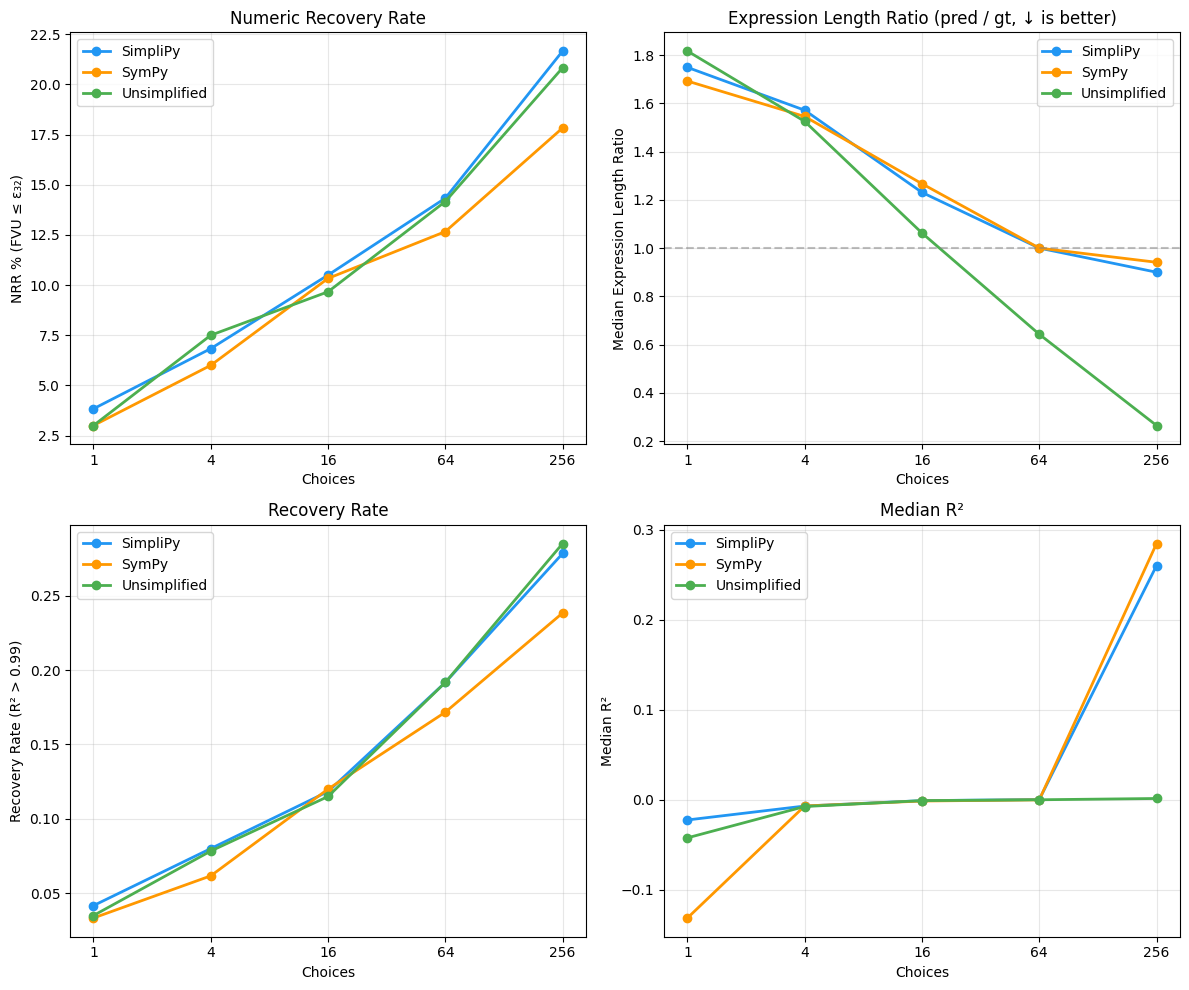

In [ ]:
# Plot: NRR, Expression Length Ratio, Recovery Rate, Median R²
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

# NRR
ax = axes[0, 0]
for model, label, color in zip(models, labels, colors):
    vals = [metrics[model][c]['nrr'] for c in choices_list]
    ax.plot(choices_list, vals, 'o-', label=label, color=color, linewidth=2, markersize=6)
ax.set_xscale('log', base=2)
ax.set_xlabel('Choices')
ax.set_ylabel(f'NRR % (FVU ≤ ε₃₂)')
ax.set_title('Numeric Recovery Rate')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(choices_list)
ax.set_xticklabels(choices_list)

# Expression Length Ratio
ax = axes[0, 1]
for model, label, color in zip(models, labels, colors):
    vals = [metrics[model][c]['median_length_ratio'] for c in choices_list]
    ax.plot(choices_list, vals, 'o-', label=label, color=color, linewidth=2, markersize=6)
ax.set_xscale('log', base=2)
ax.set_xlabel('Choices')
ax.set_ylabel('Median Expression Length Ratio')
ax.set_title('Expression Length Ratio (pred / gt, ↓ is better)')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(choices_list)
ax.set_xticklabels(choices_list)

# Recovery Rate
ax = axes[1, 0]
for model, label, color in zip(models, labels, colors):
    rates = [metrics[model][c]['recovery_rate'] for c in choices_list]
    ax.plot(choices_list, rates, 'o-', label=label, color=color, linewidth=2, markersize=6)
ax.set_xscale('log', base=2)
ax.set_xlabel('Choices')
ax.set_ylabel('Recovery Rate (R² > 0.99)')
ax.set_title('Recovery Rate')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(choices_list)
ax.set_xticklabels(choices_list)

# Median R²
ax = axes[1, 1]
for model, label, color in zip(models, labels, colors):
    med_r2 = [metrics[model][c]['median_r2'] for c in choices_list]
    ax.plot(choices_list, med_r2, 'o-', label=label, color=color, linewidth=2, markersize=6)
ax.set_xscale('log', base=2)
ax.set_xlabel('Choices')
ax.set_ylabel('Median R²')
ax.set_title('Median R²')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(choices_list)
ax.set_xticklabels(choices_list)

plt.tight_layout()
plt.show()

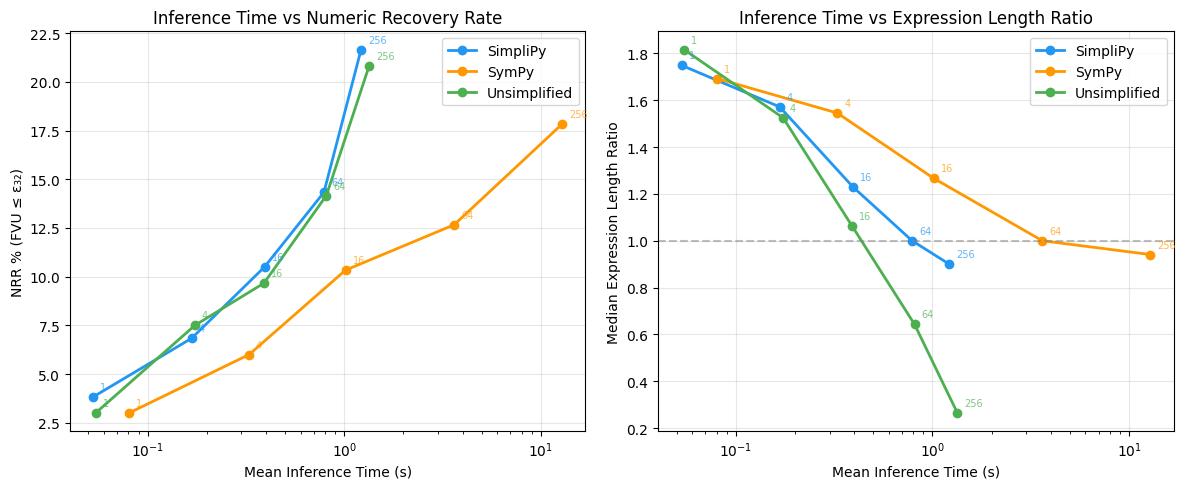

In [5]:
# Plot: Inference Time vs NRR and Inference Time vs Expression Length Ratio
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

# Inference Time vs NRR
ax = axes[0]
for model, label, color in zip(models, labels, colors):
    x = [metrics[model][c]['mean_fit_time'] for c in choices_list]
    y = [metrics[model][c]['nrr'] for c in choices_list]
    ax.plot(x, y, 'o-', label=label, color=color, linewidth=2, markersize=6)
    for c, xi, yi in zip(choices_list, x, y):
        ax.annotate(str(c), (xi, yi), textcoords='offset points', xytext=(5, 5), fontsize=7, color=color, alpha=0.7)
ax.set_xscale('log')
ax.set_xlabel('Mean Inference Time (s)')
ax.set_ylabel(f'NRR % (FVU ≤ ε₃₂)')
ax.set_title('Inference Time vs Numeric Recovery Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# Inference Time vs Expression Length Ratio
ax = axes[1]
for model, label, color in zip(models, labels, colors):
    x = [metrics[model][c]['mean_fit_time'] for c in choices_list]
    y = [metrics[model][c]['median_length_ratio'] for c in choices_list]
    ax.plot(x, y, 'o-', label=label, color=color, linewidth=2, markersize=6)
    for c, xi, yi in zip(choices_list, x, y):
        ax.annotate(str(c), (xi, yi), textcoords='offset points', xytext=(5, 5), fontsize=7, color=color, alpha=0.7)
ax.set_xscale('log')
ax.set_xlabel('Mean Inference Time (s)')
ax.set_ylabel('Median Expression Length Ratio')
ax.set_title('Inference Time vs Expression Length Ratio')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Summary table at choices=256
print(f'{"Model":<25s} {"NRR %":>8s} {"Recovery":>10s} {"Med R²":>10s} {"Med Len Ratio":>14s}')
print('-' * 70)
for model, label in zip(models, labels):
    m = metrics[model][256]
    print(f'{label:<25s} {m["nrr"]:>8.1f} {m["recovery_rate"]:>10.3f} {m["median_r2"]:>10.4f} {m["median_length_ratio"]:>14.3f}')

Model                        NRR %   Recovery     Med R²  Med Len Ratio
----------------------------------------------------------------------
SimpliPy                      21.7      0.278     0.2599          0.900
SymPy                         17.8      0.238     0.2844          0.941
Unsimplified                  20.8      0.285     0.0012          0.265


In [12]:
for i in range(20):
    print(results['v23.0-20M-A-S1'][256]['skeleton'][i])
    print(results['v23.0-20M-A-S1'][256]['predicted_skeleton_prefix'][i])
    print()

['*', 'x1', '*', 'x2', '/', 'x3', 'x4']
['*', '<constant>', '*', 'pow2', 'x1', '/', 'x2', '/', '-', '*', '<constant>', 'x4', 'x3', '-', '/', '-', 'pow1_4', 'x2', 'x1', 'x4', 'pow4', 'x3']

['*', 'x1', '*', 'x2', '/', 'x3', 'x4']
['pow5', '*', '<constant>', '*', 'x1', '*', 'x2', '-', 'x1', 'x3']

['*', 'x1', '*', 'x2', '/', 'x3', 'x4']
['/', '*', '<constant>', '*', 'x3', '/', 'x2', '/', 'pow4', 'log', 'x2', 'x1', 'x4']

['*', 'x1', '*', 'x2', '/', 'x3', 'x4']
['neg', '*', 'pow2', 'x1', '*', 'pow2', 'x3', '/', '/', 'x2', 'x4', '*', '<constant>', '+', 'pow1_5', 'x1', '/', '/', 'x4', 'pow2', 'x2', 'x3']

['*', 'x1', '*', 'x2', '/', 'x3', 'x4']
['tan', '*', '<constant>', '*', '/', '+', 'x2', 'pow5', '*', '<constant>', 'x2', 'x4', '*', '+', 'x1', 'x2', '*', '/', '*', 'x1', 'tan', 'x3', '-', 'atan', 'x2', 'x3', 'x3']

['/', 'x1', '*', '<constant>', '+', 'x2', '<constant>']
['*', '-', 'x2', '<constant>', '+', '<constant>', '/', 'x1', '*', 'x2', '-', '<constant>', '+', 'x1', '/', '+', '<constan